# Sales Explanatory Data Analysis

In [24]:
%pip install seaborn
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print("Setup Complete")

Setup Complete


In [187]:
retail = pd.read_csv("clean_sales_data.csv", index_col = "transaction_id", parse_dates = ['date'], dayfirst = True)
retail.head()

<ipython-input-187-aa0b952522e5>:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  retail = pd.read_csv("clean_sales_data.csv", index_col = "transaction_id", parse_dates = ['date'], dayfirst = True)


,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
transaction_id,,,,,,,,
1,2023-11-24,CUST001,Male,34,Beauty,3,50.0,150
2,2023-02-27,CUST002,Female,26,Clothing,2,500.0,1000
3,2023-01-13,CUST003,Male,50,Electronics,1,30.0,30
4,2023-05-21,CUST004,Male,37,Clothing,1,500.0,500
5,2023-05-06,CUST005,Male,30,Beauty,2,50.0,100


## Overall Sales Performance

In [199]:
#1) What is the total revenue and number of transactions in the dataset?
total_revenue = sum(retail.total_amount)
transaction_count = int(retail.total_amount.count())
print((total_revenue,transaction_count))

(456000, 1000)


From this table we see that the total revenue is 456000 and the number of transactions is 1000.

<ipython-input-200-cac050a9579f>:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data = retail["total_amount"], shade = True)


count    1000.000000
mean      456.000000
std       559.997632
min        25.000000
25%        60.000000
50%       135.000000
75%       900.000000
max      2000.000000
Name: total_amount, dtype: float64


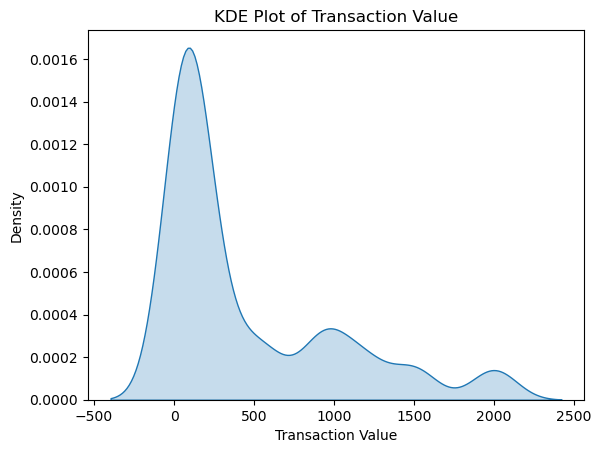

In [200]:
#2) What is the distribution of transaction value?
sns.kdeplot(data = retail["total_amount"], shade = True)
plt.xlabel("Transaction Value")
plt.title("KDE Plot of Transaction Value")
summary = retail.total_amount.describe()
print(summary)

The distribution of transaction values is right-skewed:the median order value is 135, the middle 50% of transactions fall in the range between 60 and 900, and a few large orders reach up to 2000.

## Time-Based Analysis

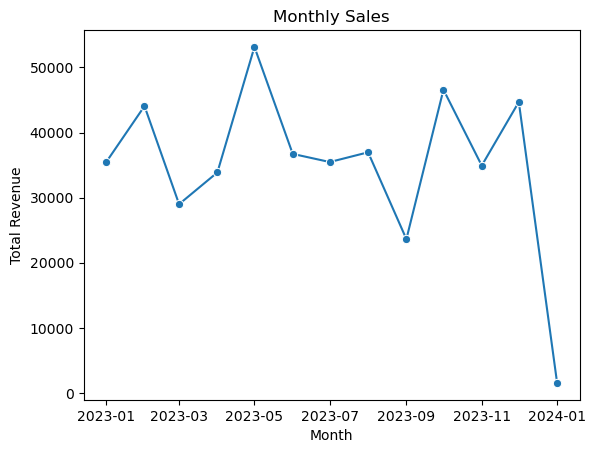

In [201]:
#1) How do monthly sales evolve over the year(s)?
monthly_sales = retail.groupby(retail.date.dt.to_period('M'))["total_amount"].sum().reset_index().rename(columns = {'date' : 'month', 'total_amount' : 'total_revenue'})
monthly_sales['month'] = monthly_sales['month'].dt.to_timestamp()
sns.lineplot(data = monthly_sales, x = 'month', y = 'total_revenue', marker = 'o')
plt.xlabel('Month')
plt.ylabel("Total Revenue")
plt.title("Monthly Sales")
plt.show()

Monthly sales fluctuate between roughlty £25k and £55k over 2023, with a noticeable peak around May and smaller peaks later in the year, but there is no strng upward or downward trend overall. The very low value at 2024-01 reflects only one day of data for that month in this dataset, so it should be treated as incomplete rather than a real sales drop.

<Axes: xlabel='day', ylabel='total_revenue'>

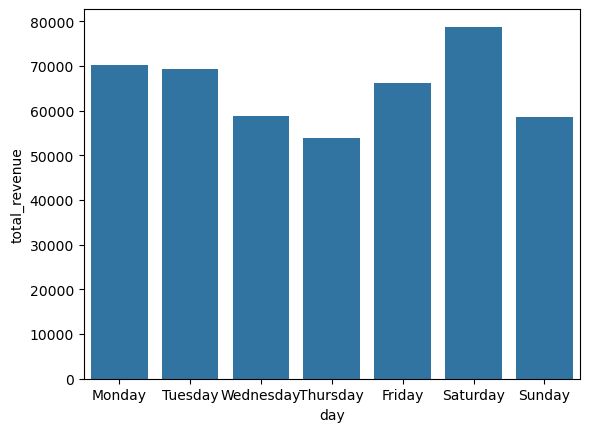

In [202]:
#2) Are sales higher on certain weedkdays?
weekly_sales = retail.groupby(retail.date.dt.day_name())["total_amount"].sum().reset_index().rename(columns = {'date' : 'day', 'total_amount' : 'total_revenue'})
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_sales['day'] = pd.Categorical(weekly_sales['day'], categories = order, ordered = True)
sns.barplot(x = weekly_sales.day, y = weekly_sales.total_revenue)

Sales peak on Saturdays, with revenue clearly higher than on weekdays, while Thursdays generate the lowest revenue.  This suggests that weekend shopping behaviour drives more spending than mid‑week, possibly because customers are less constrained by work.

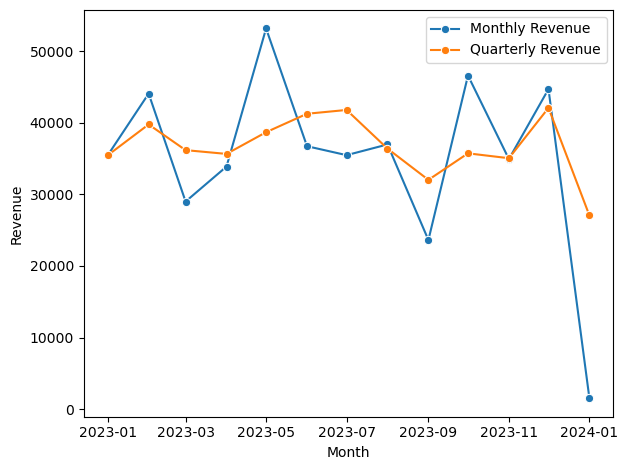

In [203]:
#3) If you compute a 3-month rolling average, what does the smoothed revenue trend look like?
monthly_sales['quarterly_revenue'] = monthly_sales['total_revenue'].rolling(window = 3, min_periods = 1).mean()
sns.lineplot(data = monthly_sales, x = 'month', y = 'total_revenue', marker = 'o', label = 'Monthly Revenue')
sns.lineplot(data = monthly_sales, x = 'month', y = 'quarterly_revenue', marker = 'o', label = 'Quarterly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

Monthly revenue is quite volatile from month to month, but the 3‑month rolling average line is much smoother and stays within a fairly narrow band, indicating that underlying revenue is relatively stable over the year despite short‑term spikes and dips. The smoothed line peaks around the middle of the year and again towards late 2023, but there is no strong long‑term upward or downward trend overall.

## Product/Category Performance

In [204]:
#1) Which product category generates the highest total revenue? Which sells the most units?
category_rev = retail.groupby(retail.product_category)['total_amount'].sum().reset_index().rename(columns = {'product_category' : "Product Category", 'total_amount' : "Total Revenue"}).set_index("Product Category")
category_quantity = retail.groupby(retail.product_category)['quantity'].sum().reset_index().rename(columns = {'product_category' : "Product Category", 'quantity' : "Quantity"}).set_index("Product Category")
category = category_rev.join(category_quantity).sort_values("Total Revenue", ascending = False)
print(category)

                  Total Revenue  Quantity
Product Category                         
Electronics              156905       849
Clothing                 155580       894
Beauty                   143515       771


Electronics has the highest revenue out of the three product category, whereas Clothing has the highest quantities sold.

                  Average Price Per Unit  Quantity  Total Revenue
Product Category                                                 
Beauty                        184.055375  2.511401         143515
Clothing                      174.287749  2.547009         155580
Electronics                   181.900585  2.482456         156905


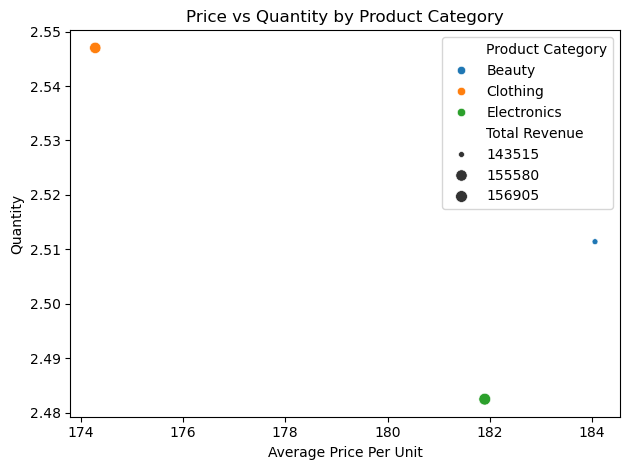

In [205]:
#2) Does any category rely on high prices vs high quantities to drive revenue (e.g. Electronics vs Beauty vs Clothing)?
avg_price_unit = retail.groupby(retail.product_category)['price_per_unit'].mean().reset_index().rename(columns = {'product_category' : "Product Category", "price_per_unit" : "Average Price Per Unit"}).set_index("Product Category")
avg_quantity_per_order = retail.groupby(retail.product_category)['quantity'].mean().reset_index().rename(columns = {'product_category' : "Product Category", "quantity" : "Quantity"}).set_index("Product Category")
initial_table = avg_price_unit.join(avg_quantity_per_order)
price_v_quantity = initial_table.join(category_rev)
print(price_v_quantity)
sns.scatterplot(data = price_v_quantity, x = "Average Price Per Unit", y = "Quantity", size = "Total Revenue", hue = "Product Category")
plt.title("Price vs Quantity by Product Category")
plt.tight_layout()
plt.show()

The scatter plot shows that Electronics is price-driven, with high average unit prices and modest quantities, while Clothing is volume-driven, with lower prices but much higher quantities per order. This indicates different revenue strategies across categories.

In [206]:
#3) Within each category, what is the average transaction value and median quantity per transaction?
ATV = retail.groupby(retail.product_category)['total_amount'].mean().reset_index().rename(columns = {'product_category' : "Product Category", 'total_amount' : "Average Transaction Value"}).set_index("Product Category")
median = retail.groupby(retail.product_category)['quantity'].median().reset_index().rename(columns = {'product_category' : "Product Category", 'quantity' : "Median Quantity"}).set_index("Product Category")
category_stats = ATV.join(median)
print(category_stats)

                  Average Transaction Value  Median Quantity
Product Category                                            
Beauty                           467.475570              3.0
Clothing                         443.247863              3.0
Electronics                      458.786550              2.0


Beauty and Clothing generate similar average spend per transactions (around 440 - 470), but customers usually buy 3 items per order, whereas Electronics achieves a comparable average spend with only 2 iterms per order, suggesting higher prices per unit in Electronics. 

## Customer Behaviour and Segments

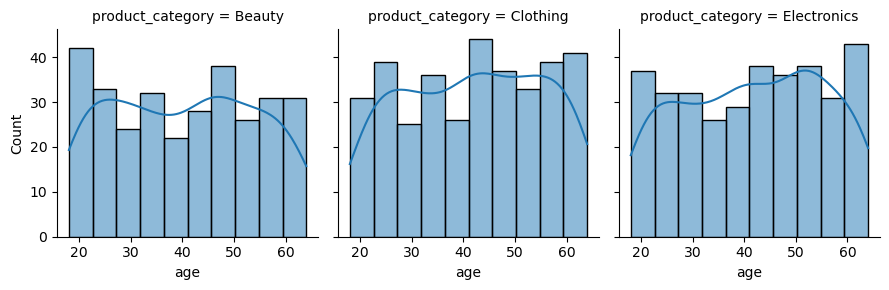

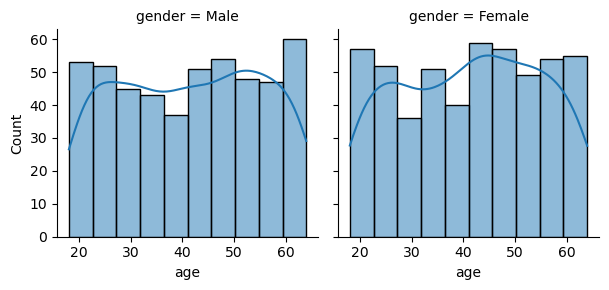

In [207]:
#1) How is customer age distributed overall, and does it differ across categories or gender?
sns.displot(data = retail, x = 'age', col = 'product_category', bins = 10, kde = True, col_wrap = 3, height = 3)
sns.displot(data = retail, x = 'age', col = 'gender', bins = 10, kde = True, col_wrap = 3, height = 3)

Customer ages for Beauty, Clothing and Electronics are broadly similar, with most shippers between their 20s and early 60s and no category being strongly concentrated in a single age band. Electronics appears to skew slightly towards older customers (around 40-55), while Beauty and Clothing have a bit more presence among younger adults, but overall the age mix is fairly balanced across categories. This suggestst that product categories in this dataset appeal to a wide age range rather than being targeted at a very narrow age segment.

The age distributions for male and female customers are very similar; most transactions come from customers in their 20s to early 60s, with no major age band that is unique to one gender. Female customers show slightly stronger concentration around the 40-50 range, but overall the age mix is broadly comparable between genders.

  Age Band  Revenue  Percentage of Revenue
0    18-25    84550              18.541667
1    26-35    98480              21.596491
2    36-45    91870              20.146930
3    46-55   100690              22.081140
4      56+    80410              17.633772


Text(0.5, 1.0, 'Revenue Share by Age Band')

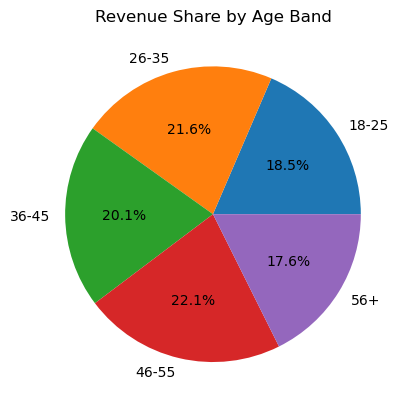

In [208]:
#2) Which age bands contribute the most revenue?
bins = [18, 25, 35, 45, 55, 200]
labels = ['18-25', '26-35', '36-45', '46-55', '56+']
retail['age_band'] = pd.cut(retail['age'], bins = bins, labels = labels, right = True, include_lowest = True)
age_rev = retail.groupby(retail.age_band)['total_amount'].sum().reset_index().rename(columns = {'age_band' : "Age Band", 'total_amount' : "Revenue"})
total_rev = age_rev['Revenue'].sum()
age_rev["Percentage of Revenue"] = age_rev['Revenue']*100/total_rev
print(age_rev)
plt.pie(age_rev["Percentage of Revenue"], labels = age_rev["Age Band"], autopct = '%.1f%%')
plt.title("Revenue Share by Age Band")

Revenue is highest among customers aged 46-55, followed by 26-35 and 36-45, while 56+ and 18-25 bands contributes the smallest shares. This indicates that mid-age customers (roughly 26-55) drive most of the sales in this dataset.

## Portfolio-Style Questions

In [216]:
#1) What are the top 10 customers by total revenue, and what share of overall revenue do they represent?
top_10 = retail.sort_values(by = "total_amount", ascending = False)[:10]
top_10["share_of_revenue"] = top_10['total_amount']*100/total_rev
print(top_10["share_of_revenue"])

transaction_id
572    0.438596
89     0.438596
503    0.438596
561    0.438596
832    0.438596
808    0.438596
577    0.438596
946    0.438596
447    0.438596
735    0.438596
Name: share_of_revenue, dtype: float64


In [231]:
#2) If you bucket transactions into low / medium / high value (e.g. tertiles by Total Amount), how do those buckets differ by category, age band, and gender?
retail['value_band'] = pd.qcut(retail['total_amount'], q = 3, labels = ['Low', 'Medium', 'High'])
tertiles_product = retail.groupby(['value_band', 'product_category'], as_index = True).agg(transactions = ('total_amount', 'count'), total_revenue = ('total_amount', 'sum'))
print(tertiles_product)

                             transactions  total_revenue
value_band product_category                             
Low        Beauty                     110           6015
           Clothing                   121           6450
           Electronics                118           5975
Medium     Beauty                     100          20400
           Clothing                   128          26930
           Electronics                124          26630
High       Beauty                      97         117100
           Clothing                   102         122200
           Electronics                100         124300


Across low, medium and high value bands, transaction counts are fairly evenly distributed across Beauty, Clothing and Electronics, but in the high-value segment Electronics and Clothing generate slightly more revenue than Beauty. This suggests that very high-value orders are spread across all categories, with a modest concentration in Electronics and Clothing.

In [232]:
tertiles_age = retail.groupby(['value_band', 'age_band'], as_index = True).agg(transactions = ('total_amount', 'count'), total_revenue = ('total_amount', 'sum'))
print(tertiles_age)

                     transactions  total_revenue
value_band age_band                             
Low        18-25               69           3710
           26-35               64           3620
           36-45               77           3840
           46-55               65           3410
           56+                 74           3860
Medium     18-25               45          10740
           26-35               78          16560
           36-45               63          12130
           46-55               98          20080
           56+                 68          14450
High       18-25               55          70100
           26-35               63          78300
           36-45               62          75900
           46-55               66          77200
           56+                 53          62100


Low-value transactions are spread fairly evenly across age bands, but medium- and especially high-value revenue is dominated by customers aged 26-55. Younger (18-25) and older (56+) customers still place high-value orders, but their revenue contribution in the high band is noticable smaller, confirming that middle-age customers drive most of the largest transactions. 

In [233]:
tertiles_gender = retail.groupby(['value_band', 'gender'], as_index = True).agg(transactions = ('total_amount', 'count'), total_revenue = ('total_amount', 'sum'))
print(tertiles_gender)

                   transactions  total_revenue
value_band gender                             
Low        Female           178           9550
           Male             171           8890
Medium     Female           177          37190
           Male             175          36770
High       Female           155         186100
           Male             144         177500


Low- and medium-value transactions are split almost evenly between male and female customers, but high-value orders are slightly more common and generate slightly more revenue among female customers. Overall, both genders participate across all value bands, with only a small tilt towards females in the high-value segment.